# <img style="float: left; padding-right: 10px; width: 45px" src="https://raw.githubusercontent.com/Harvard-IACS/2018-CS109A/master/content/styles/iacs.png"> Data Science 2: Advanced Topics in Data Science
## Project Group 109: Predicting Canadian GDP Using Deep Learning

**Authors**: Zainab Zarnish, Muhammad Jawed, Mohammed Sakib, Hawraz Jamal <br/>
**Harvard University**<br/>
**Spring 2025**<br/>
**Instructors**: Pavlos Protopapas, Natesh Pillai, & Chris Gumb<br/>
**TF**: Christian Aagnes 


<hr style="height:2pt">


<a id="contents"></a>

## Notebook Contents

- [**PART 1: Introduction**](#Part1)

- [**PART 2: Description of Data**](#Part2)

- [**PART 3: EDA and Visualization**](#part3)
    - [Testing for Data Imbalance](#part3a)
    - [Colinearity](#part3b)
    - [PCA](#part3c)
- [**PART 4: Baseline Models**](#part4)
    - [Naive](#part4aa)
    - [RNN](#part4a)
    - [LSTM](#part4b)
- [**PART 5: Time Series Transformer**](#part5)

- [**PART 6: Result Comparison & Conclusions**](#part6)

- [**PART 7: Next Steps**](#part7)

*Flowchart of our approach, where we started by exploring the data, followed by running an RNN model. After which, we tried to improve using an LSTM model, and then implemented a transformer model to better predict the spikes on our GDP, evaluating our models and drawing on conclusions from it*

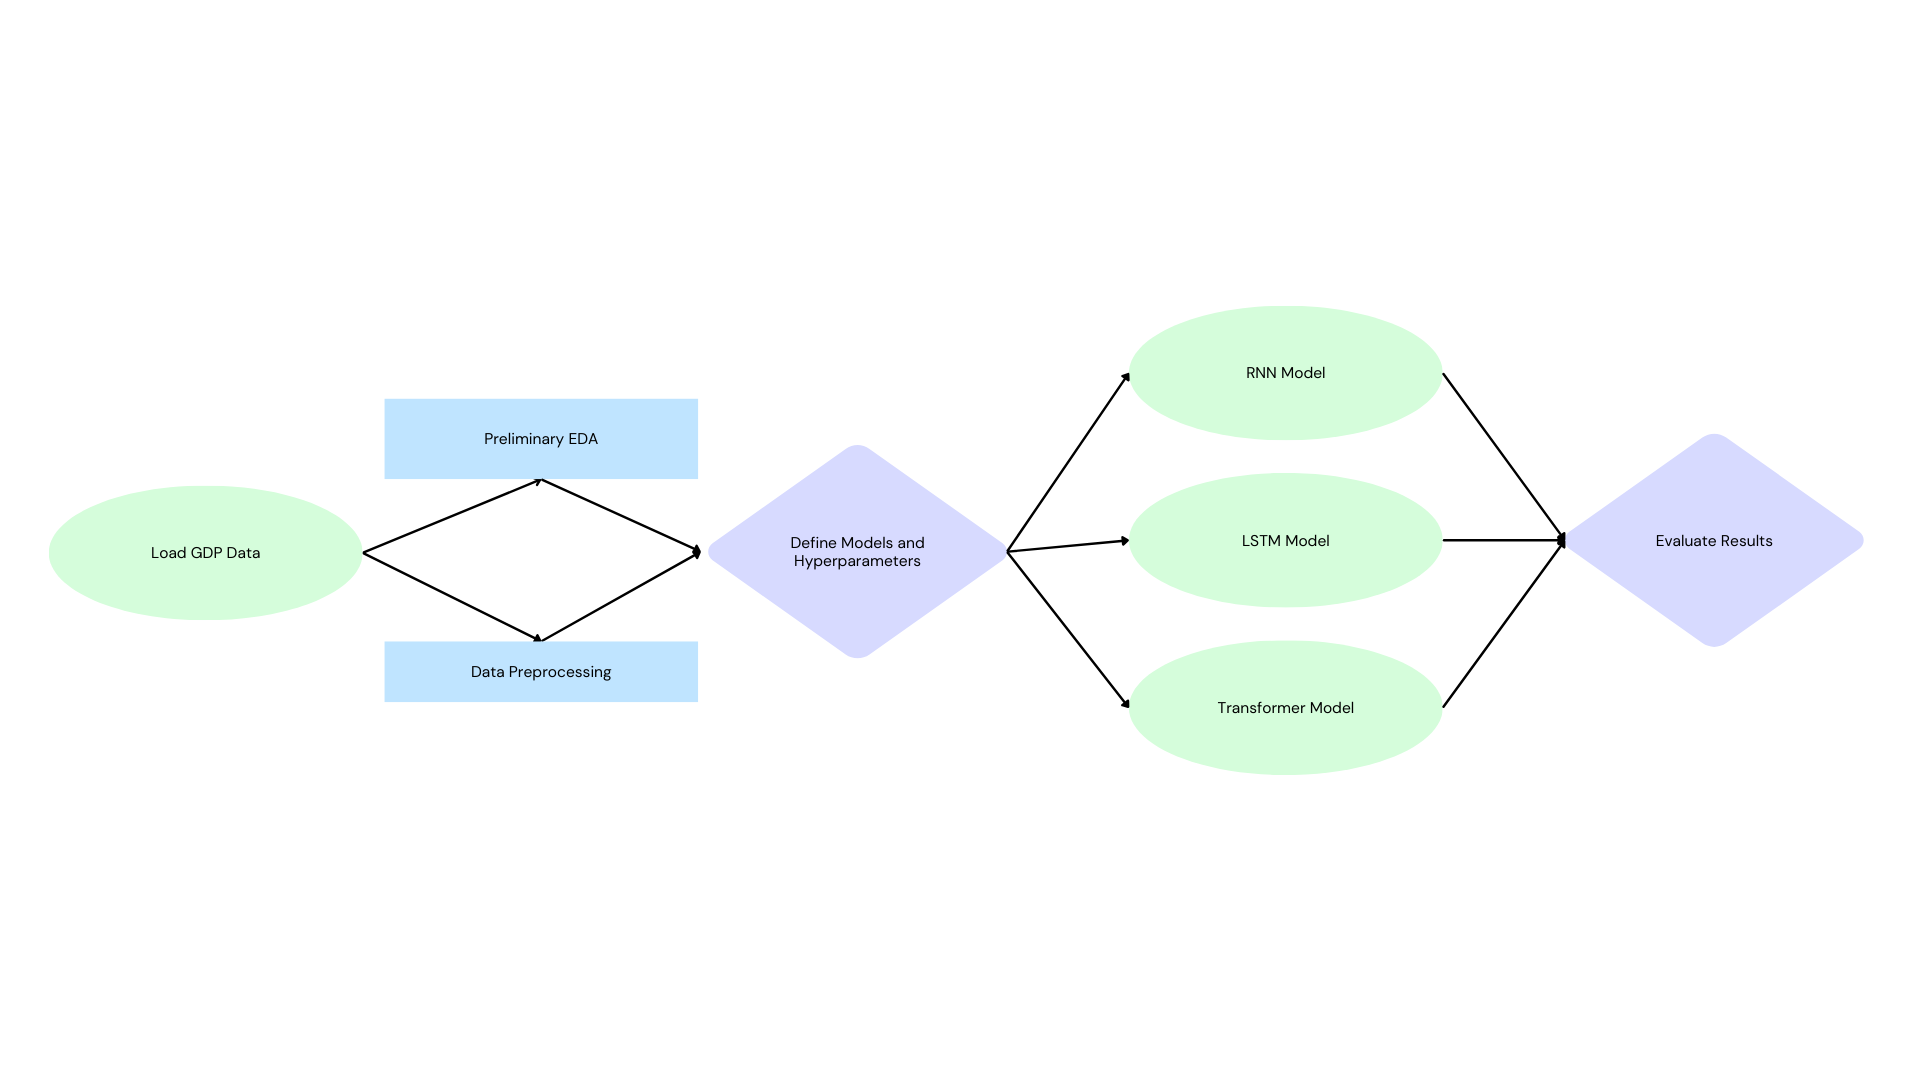

*Used ChatGPT for code debugging.*

<a id="Part1"></a>

<div style="background-color:#f0f8ff; padding:18px; font-size:12px; line-height:1.5; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h1 style="margin-top:0; color:#2c3e50; font-size:26px;">Part 1: Introduction</h1>
<p><a href="#contents" style="font-size:11px; color:#2980b9;">Return to contents</a></p>

<p>
Real GDP is a measure of a country’s economic health, and it helps policy makers and business investors make better informed decisions with accurate short-term forecasting models. Traditional forecasting models in comparison to deep learning networks fail to predict economic changes with high-dimensional feature spaces. Issues like multicollinearity, overfitting, and dimensionality result in a failure to capture complex relationships among various economic indicators, resulting in poor predictions.
</p>

<p>
This accurate forecasting of GDP is a growing concern for Canada as it becomes more globally interconnected, relying on multiple inputs for its GDP predictions. With the rise of deeper learning and transformer models, we can better process high-dimensional data, and create more accurate short-term GDP predicting models for Canada's GDP, like those that exist for the United States of America. Obtaining data from the 
<a href="https://www.stevanovic.uqam.ca/DS_LCMD.html" target="_blank" style="color:#2980b9;">
Large Canadian Database for Macroeconomic Analysis</a> (LCDMA), we aim to answer the following question:
</p>

<blockquote style="font-weight:bold; border-left: 4px solid #2980b9; padding-left: 12px; color:#2c3e50;">
Can we forecast next-month Canadian real GDP growth using the preceding m-month sequence of relevant macroeconomic indicators and which features are most predictive of future GDP performance across different economic conditions?
</blockquote>

</div>

<a id="Part2"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 2: Description of Data</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<h3 style="color:#2c3e50; margin-top:24px;">Importing the libraries necessary</h3>

<p>
Before working with the data, we need to import all the essential Python libraries for data handling, visualization, and model building, where <code>NumPy</code> and <code>Pandas</code> are used for numerical computations and data manipulation. We rely on <code>Matplotlib</code> and <code>Seaborn</code> for our visualization plots. We import tools from <code>Scikit-learn</code> such as <code>StandardScaler</code> and <code>PCA</code> for preprocessing and to see which PCA components are most valuable, while evaluation metrics like <code>mean square error (MSE)</code>, <code>mean absolute error (MAE)</code>, and <code>R² score</code> assess model performance. 
</p>

<p>
For our deep learning models, we use <code>TensorFlow</code> and its high-level API <code>Keras</code>, ranging from <code>SimpleRNN</code>, <code>LSTM</code> layers, <code>Dense</code>, <code>Dropout</code>, and <code>BatchNormalization</code> to optimize our model performance with the help of training tools like <code>Adam</code>, <code>EarlyStopping</code>, <code>ModelCheckpoint</code>, and <code>ReduceLROnPlateau</code>. We also rely on <code>PyTorch</code> as another deep learning framework, using its <code>DataLoader</code> and <code>Dataset</code> to build and train neural networks. The <code>time</code> library allows us to assess how long it took our model to perform the way it did.
</p>

</div>

In [1]:
# Imports for the notebook
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
#from sklearn.cluster import KMeans

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Concatenate, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import tensorflow as tf
import time

2025-05-09 21:41:10.175045: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-09 21:41:10.175093: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-09 21:41:10.205245: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-09 21:41:10.259078: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load the GDP data from drive and analyze the shape
file_path = 'balanced_can_md.csv'
df = pd.read_csv(file_path)

print("Shape:", df.shape)
df.info()
df.describe().T

Shape: (529, 411)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 529 entries, 0 to 528
Columns: 411 entries, Date to CRE_BUS_discontinued
dtypes: float64(410), object(1)
memory usage: 1.7+ MB


,count,mean,std,min,25%,50%,75%,max
GDP_new,529.0,0.001889,0.007835,-0.109011,-0.000128,0.002003,0.004460,0.055510
BSI_new,529.0,0.002017,0.008903,-0.123894,-0.000570,0.002261,0.005127,0.064754
GPI_new,529.0,0.001279,0.011578,-0.159704,-0.003104,0.001334,0.007217,0.077833
SPI_new,529.0,0.002177,0.007199,-0.090330,0.000473,0.002331,0.003838,0.056499
IP_new,529.0,0.001263,0.013356,-0.163341,-0.004291,0.001459,0.008587,0.055787
...,...,...,...,...,...,...,...,...
CRED_T_discontinued,477.0,0.005553,0.003147,-0.003022,0.003644,0.005157,0.007076,0.023270
CRED_HOUS_discontinued,477.0,0.005919,0.003516,-0.009821,0.003994,0.005252,0.007665,0.031100
CRED_MORT_discontinued,477.0,0.006114,0.003836,-0.013530,0.003860,0.005557,0.007867,0.035325
CRED_CONS_discontinued,477.0,0.005461,0.004787,-0.019545,0.002237,0.005434,0.008619,0.022588


In [3]:
columns = df.columns
print(columns.tolist())

['Date', 'GDP_new', 'BSI_new', 'GPI_new', 'SPI_new', 'IP_new', 'NDM_new', 'DM_new', 'OILP_new', 'CON_new', 'RT_new', 'WT_new', 'PA_new', 'FIN_new', 'OIL_CAN_new', 'EMP_CAN', 'EMP_SERV_CAN', 'EMP_FOR_OIL_CAN', 'EMP_CONS_CAN', 'EMP_SALES_CAN', 'EMP_FIN_CAN', 'EMP_MANU_CAN', 'EMP_PART_CAN', 'UNEMP_CAN', 'UNEMP_DURA_1.4_CAN', 'UNEMP_DURA_5.13_CAN', 'UNEMP_DURA_14.25_CAN', 'UNEMP_DURA_27._CAN', 'UNEMP_DURAvg_CAN_new', 'CLAIMS_CAN', 'TOT_HRS_CAN', 'GOOD_HRS_CAN', 'GOOD_OVT_HRS_CAN', 'NHOUSE_P_CAN', 'NHOUSE_P_NF', 'NHOUSE_P_PEI', 'NHOUSE_P_NS', 'NHOUSE_P_NB', 'NHOUSE_P_QC', 'NHOUSE_P_ONT', 'NHOUSE_P_MAN', 'NHOUSE_P_SAS', 'NHOUSE_P_ALB', 'NHOUSE_P_BC', 'hstart_CAN_new', 'hstart_NF_new', 'hstart_PEI_new', 'hstart_NS_new', 'hstart_NB_new', 'hstart_QC_new', 'hstart_ONT_new', 'hstart_MAN_new', 'hstart_SAS_new', 'hstart_ALB_new', 'hstart_BC_new', 'build_Total_CAN_new', 'build_Ind_CAN_new', 'build_Comm_CAN_new', 'build_Total_NF_new', 'build_Ind_NF_new', 'build_Comm_NF_new', 'build_Total_PEI_new', 'b

In [4]:
df.head()

,Date,GDP_new,BSI_new,GPI_new,SPI_new,IP_new,NDM_new,DM_new,OILP_new,CON_new,...,CPI_MINUS_FOO_BC,CPI_MINUS_FEN_BC,CPI_GOO_BC,CPI_DUR_BC,CPI_SERV_BC,CRED_T_discontinued,CRED_HOUS_discontinued,CRED_MORT_discontinued,CRED_CONS_discontinued,CRE_BUS_discontinued
0,1981-01-01,0.001345,0.000838,-0.000200,0.002242,-0.001856,-0.003871,-0.000287,-0.000775,0.002234,...,0.023086,0.016461,0.010111,0.004930,0.029917,0.013175,0.007571,0.006705,0.009307,0.017244
1,1981-02-01,0.003043,0.003461,0.004369,0.002204,0.004222,0.001718,0.012859,-0.001119,-0.001467,...,0.010320,0.014185,0.010010,0.013029,0.012552,0.013506,0.006908,0.005045,0.010629,0.018252
2,1981-03-01,-0.000820,-0.000917,-0.002830,0.000468,0.000000,0.011182,-0.002767,-0.016587,-0.007440,...,0.026344,0.019921,0.025567,0.023982,0.014448,0.012590,0.005650,0.003655,0.009610,0.017514
3,1981-04-01,0.011765,0.014779,0.017099,0.008327,0.018938,0.015594,0.013487,0.032934,0.016858,...,0.005982,0.007859,0.003876,0.000000,0.010194,0.015212,0.006308,0.004757,0.009372,0.021468
4,1981-05-01,-0.008364,-0.011973,-0.010776,-0.006796,-0.017627,-0.017293,-0.003982,-0.047584,0.009033,...,0.011858,0.009737,0.009625,0.012559,0.008081,0.014773,0.006101,0.003497,0.011210,0.020771


In [5]:
memory_usage = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"Memory usage: {memory_usage:.2f} MB")

Memory usage: 1.69 MB


<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Overview of the LCDMA Dataset</h3>

<p>
Our LCDMA (Large Canadian Database for Macroeconomic Analysis) Data contains a balanced monthly panel that covers data from January 1981 to February 2025, with 529 monthly observations, where each row contains information about one specific month, with the columns indicating specific macroeconomic variables. In addition to containing 529 months of economic data (rows) our data contains 411 columns (macroeconomic indicators), of which, 410 are numeric and the first one is the date, which we can use to index. The columns are abbreviated, where <code>GDP_new</code> represents growth rate of real GDP while <code>BSI_new</code> serves as the business sentiment index. Our dataset is approximately 1.69 MB in RAM memory, so we can efficiently process our data using ML frameworks.
</p>

<p>
We also notice that some of our data contains some discontinued columns, which we should likely explore to identify data missingness and preprocessing.
</p>

<p>
We can also explore the summary statistics. We see that the macroeconomic indicators like <code>GDP_new</code>, <code>BSI_new</code>, <code>GPI_new</code>, <code>SPI_new</code>, <code>IP_new</code> show very small average monthly changes, while occasionally having larger spikes, indicating economic shocks are at play. The distribution plots reinforce that most values are concentrated near the mean, with very small variations. The 2D scatter plots hints at some correlation between certain variables, requiring shrinking techniques before we model.
</p>

</div>

<a id="part3"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 3: EDA and Visualization</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<div style="background-color:#f9fcff; padding:16px; font-size:14px; line-height:1.6; border-radius:8px; margin-bottom:12px;">
<h3 style="color:#2c3e50; margin-top:0;">Indexing the Date Column</h3>

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df.head()
df.index

DatetimeIndex(['1981-01-01', '1981-02-01', '1981-03-01', '1981-04-01',
               '1981-05-01', '1981-06-01', '1981-07-01', '1981-08-01',
               '1981-09-01', '1981-10-01',
               ...
               '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01',
               '2024-12-01', '2025-01-01'],
              dtype='datetime64[ns]', name='Date', length=529, freq=None)

<div style="background-color:#f9fcff; padding:16px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:24px;">
<h3 style="color:#2c3e50; margin-top:0;">Now, Let's Check for Missing Values</h3>

In [7]:
missing = df.isnull().sum()
missing_val = (missing / len(df)) * 100
missing_val[missing_val > 0].sort_values(ascending=False)

CRED_T_discontinued       9.829868
CRED_HOUS_discontinued    9.829868
CRED_MORT_discontinued    9.829868
CRED_CONS_discontinued    9.829868
CRE_BUS_discontinued      9.829868
dtype: float64

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
The columns that have a lot of missing values are the ones that have been discontinued. Let's explore when these columns stop having inputs, and if they truly are discontinued, we can drop them.
</p>
</div>

In [8]:
discontinued_columns = [
    'CRED_T_discontinued',
    'CRED_HOUS_discontinued',
    'CRED_MORT_discontinued',
    'CRED_CONS_discontinued',
    'CRE_BUS_discontinued'
]

for col in discontinued_columns:
    last_valid = df[col].last_valid_index()
    print(f"{col}: Last non-null entry is on {last_valid}")

CRED_T_discontinued: Last non-null entry is on 2020-09-01 00:00:00
CRED_HOUS_discontinued: Last non-null entry is on 2020-09-01 00:00:00
CRED_MORT_discontinued: Last non-null entry is on 2020-09-01 00:00:00
CRED_CONS_discontinued: Last non-null entry is on 2020-09-01 00:00:00
CRE_BUS_discontinued: Last non-null entry is on 2020-09-01 00:00:00


<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
This means that these variables have not been updated since four and a half years ago, and since these are no longer active, nor very significant variables, we can drop them from our analysis, which will help reduce noise and bias due to missiningness. It will also help us better predict since we are not relying on discontinued values that have not been updated. Just to be on the safe side, we will drop all disconinued values since they will not be good predictors and have a lot of missing values.
</p>
</div>

In [9]:
df = df.drop(columns=[col for col in df.columns if 'discontinued' in col])
print("Remaining columns:", df.shape[1])

Remaining columns: 405


<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
We have removed the discontinued columns, and this means the remainder do not have any missing values.
</p>
</div>

<a id="part3a"></a>

<div style="background-color:#f9fcff; padding:16px; border-radius:8px; margin-bottom:16px;">
<h2 style="margin:0; color:#2c3e50;">Testing for Data Imbalance</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>
</div>

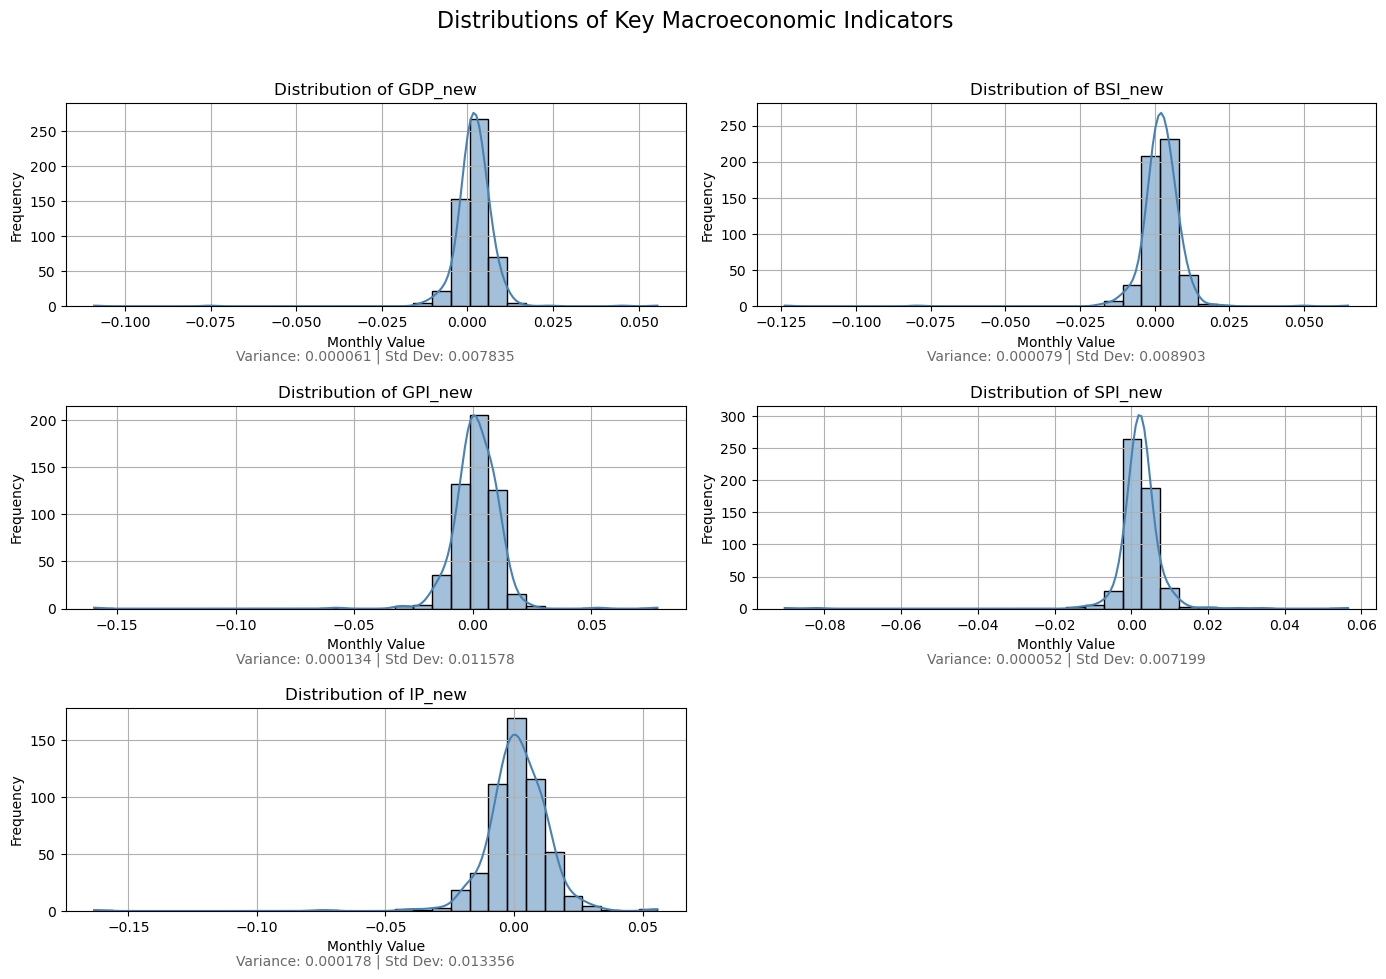

In [10]:
key_vars = ['GDP_new', 'BSI_new', 'GPI_new', 'SPI_new', 'IP_new']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {var}', fontsize=12)
    axes[i].set_xlabel('Monthly Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True)
    
    variance = df[var].var()
    std_dev = df[var].std()
    axes[i].text(0.5, -0.25,
                 f'Variance: {variance:.6f} | Std Dev: {std_dev:.6f}',
                 ha='center', va='center', transform=axes[i].transAxes,
                 fontsize=10, color='dimgray')

fig.delaxes(axes[-1])

plt.suptitle('Distributions of Key Macroeconomic Indicators', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
Our target variable GDP_new is very heavily concentrated around 0 meaning it is tightly centered and clustered near the mean. However, we see some outliers on the negative side, which is likely linked to shocks or recessions, but since we are dealing with a regression problem, we do not have to worry about data imbalance as it is not aplicable, but we have to make sure our model is sensistive to the fluctuations and accounts for economic shocks we see in this distribution. Our other variable have similar distributions concentrated around 0, with little variation, which is expected for monthly growth/change rates in macroeconomic time series. This will likely result in very small MSE and MAE. We are choosing to keep the outliers since they inform the model. The tails for all variables indicate economic shocks or policy events. 
</p>
</div>

<div style="background-color:#f9fcff; padding:16px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:24px;">
<h3 style="color:#2c3e50; margin-top:0;">Feature Scaling</h3>

In [11]:
X_raw = df.drop(columns=['GDP_new'])
y = df['GDP_new']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

X = pd.DataFrame(X_scaled, index=X_raw.index, columns=X_raw.columns)

df_scaled = X.copy()
df_scaled['GDP_new'] = y
df_scaled.drop(columns='GDP_new').describe().T[['mean', 'std']].head()

,mean,std
BSI_new,3.693748e-17,1.000947
GPI_new,1.343181e-17,1.000947
SPI_new,-1.007386e-17,1.000947
IP_new,0.000000e+00,1.000947
NDM_new,6.715905e-18,1.000947


<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
We applied Z-score standardization to all of the macroeconomic features except for our target varable, and we confirmed that they standardized correctly, with the mean close to 0 and standard deviation close to 1. This method ensures our predictors are all on the same scare and prevents bias in training our model, and it will make convergence much easier along with allowing for easier PCA, Lasso, among others.
</p>
</div>

<div style="background-color:#f9fcff; padding:16px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:24px;">
<h3 style="color:#2c3e50; margin-top:0;">Accounting for other errors</h3>

In [12]:
#Any columns are constant or repeated?
constant_columns = [col for col in df_scaled.columns if df_scaled[col].nunique() == 1]
print(f"Constant columns: {constant_columns}")

duplicate_columns = df_scaled.T[df_scaled.T.duplicated()].index.tolist()
print(f"Duplicate columns: {duplicate_columns}")

#is data skipping by months or do we have other errors?
print(df_scaled.index.to_series().diff().value_counts())


Constant columns: []
Duplicate columns: []
Date
31 days    308
30 days    176
28 days     33
29 days     11
Name: count, dtype: int64


<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
We can see our data is consistent.
</p>
</div>

<div style="background-color:#f9fcff; padding:16px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:24px;">
<h3 style="color:#2c3e50; margin-top:0;">How we intend to predict</h3>

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
Basend on previous comments (MS2), it is most relevant to use the current month's variables to predict next month's GDP. We implemented this below.
</p>
</div>

In [13]:
df_new = df.copy()

# Create next month's GDP as target
df_new['GDP_new_t+1'] = df_new['GDP_new'].shift(-1)

# Drop rows with NaN in target
df_new = df_new.dropna()

# Define X and y
X = df_new.drop(columns=['GDP_new', 'GDP_new_t+1'])
y = df_new['GDP_new_t+1']

<a id="part3b"></a>

<div style="background-color:#f9fcff; padding:16px; border-radius:8px; margin-bottom:16px;">
<h2 style="margin:0; color:#2c3e50;">Testing for Colinearity</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>
</div>

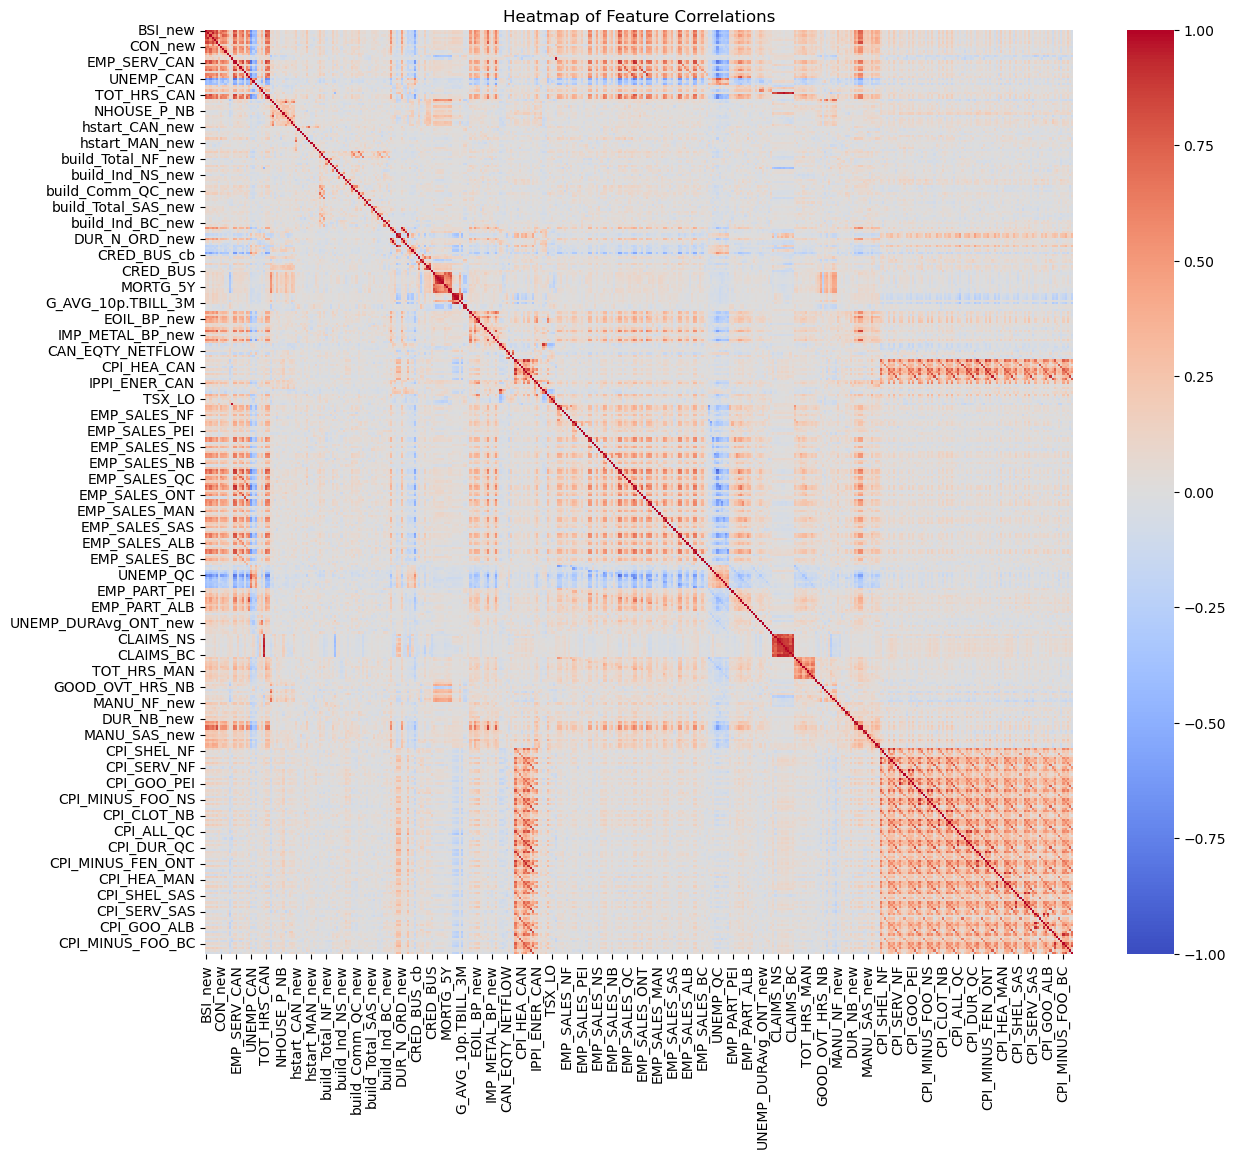

In [14]:
corr_matrix = df_scaled.drop(columns='GDP_new').corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmax=1, vmin=-1)
plt.title('Heatmap of Feature Correlations')
plt.show()

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
This is hard to read so let's look at the top correlated features.
</p>
</div>

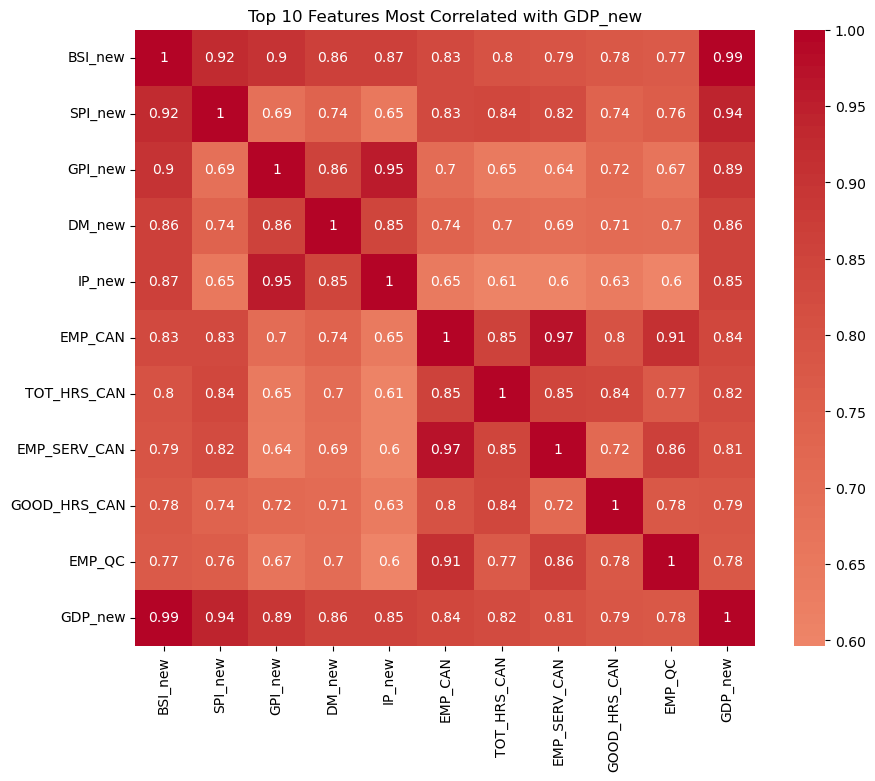

In [15]:
real_correlation = df_scaled.corr()['GDP_new'].drop('GDP_new')

top_correlated = real_correlation.abs().sort_values(ascending=False).head(10)
top_correlated_features = top_correlated.index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df_scaled[top_correlated_features + ['GDP_new']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Top 10 Features Most Correlated with GDP_new')
plt.show()

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
This heatmap indicates multicollinearity is present and we can see some features are correlated with others. This can impact our model negatively, especially the iterpretability and variance. To address this, we should use regularization or run PCA to better prepare the data for predicting.
</p>
</div>

<a id="part3c"></a>

<div style="background-color:#f9fcff; padding:16px; border-radius:8px; margin-bottom:16px;">
<h2 style="margin:0; color:#2c3e50;">PCA</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>
</div>

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
We are going to use PCA since we will be using deep learning models, and this will allow us to reduce dimensionality, multicolinearity, redundancy, while capturing the model's variance, which will improve our moddel's generalization.
</p>
</div>

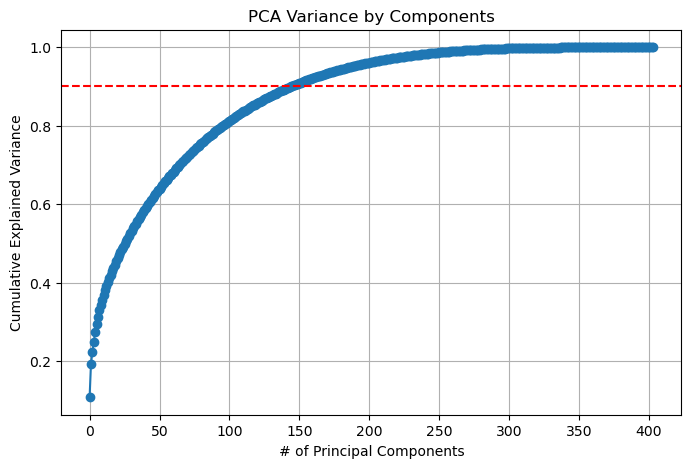

In [28]:
X_pca = df_scaled.drop(columns=['GDP_new'])

pca = PCA()
X_x = pca.fit_transform(X_pca)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('# of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance by Components')
plt.axhline(y=0.90, color='r', linestyle='--')
plt.grid(True)
plt.show()


<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
We see that 90% of variance in data is the result of the first 150 principal compnents, so we can reduce our features while maintaing the model's content. This can reduce complexity and overfitting while improving training time.
</p>
</div>

In [29]:
pca = PCA(n_components=150)
X_reduced = pca.fit_transform(X_pca)
X_reduced_df = pd.DataFrame(X_reduced, index=df_scaled.index, columns=[f'PC{i+1}' for i in range(150)])
X_reduced_df['GDP_new'] = df_scaled['GDP_new']

In [30]:
X_reduced_df.corr()['GDP_new'].drop('GDP_new').sort_values(ascending=False).head(10)

PC11    0.130339
PC8     0.101364
PC14    0.088418
PC30    0.088108
PC3     0.078207
PC9     0.064304
PC88    0.064149
PC15    0.058167
PC83    0.049097
PC52    0.048474
Name: GDP_new, dtype: float64

<div style="background-color:#f9fcff; padding:14px; font-size:14px; line-height:1.6; border-radius:8px; margin-top:12px;">
<p>
Above, we see the top 10 principal components that are most correlated with GDP_new and the level of correlation.
</p>
</div>

<a id="part4"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 4: Baseline Models</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<h3 style="color:#2c3e50;">Baseline Implementation Plan: RNN</h3>

<p>
For a baseline implementation, we start by splitting the data into 3 segments: train, validation, and test sets. For the training data, we will:
</p>

<ol>
<li>PCA the data into $n$ components, where $n$ is a hyperparameter.</li>
<li>We split the data into smaller $m$-month windows or sequences and predict the next data point. As in, a set of sequences and a set of target values. $m$ is another hyperparameter.</li>
<li>Train a simple RNN to predict the next month based on the $m$ length sequence of months.</li>
<li>Test the generalization of the data on the validation set.</li>
</ol>

<h3 style="color:#2c3e50;">Model Architecture</h3>

<ol>
<li>Take in an input layer with size $(n \times m)$ and no shuffling of the data because it is a time series.</li>
<li>Simple RNN layer so we can capture sequential patterns in the data.</li>
<li>Dense layer with ReLU activation which will introduce non-linearity and transform the RNN outputs into an enhanced feature representation.</li>
<li>Output layer will apply a linear activation function to produce continuous estimates of the next month's PCA components.</li>
</ol>

<p>We will test try to recude our loss fuction.</p>

<h3 style="color:#2c3e50;">Hyper-parameters to tune:</h3>

<ol>
<li>$n$, the number PCA components.</li>
<li>$m$, the length of the time-sequence.</li>
<li>Number of units in the RNN and Dense layers.</li>
<li>Learning rate.</li>
</ol>

<h3 style="color:#2c3e50;">Reason to choose this as our baseline model:</h3>

<p>
Implementing a simple RNN model will allow us to have a clear and easily interpretable starting point which we can use to evealuate how a basic sequencing model performs on our dataset. By using a model with less complexity, we can benchmark improvements when we implement more advanced models down the line or feature engineer, whether that is tuning the learning rate or implementing LSTM layers. This is a great starting point!
</p>

</div>

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Data Pre-processing Pipeline</h3>

<p>
<em>After removing missing values, we standardized our feature columns to prepare for PCA, after which, we applied 100 components, reducing dimensionality while capturing the data's variance. We initially started with 150 following our EDA analysis, but discovered 100 components gave the lowest MSE, likely because our EDA compenent analysis of 150 components captured most of the data's variance, but with it, it captured noise, and using 100 components removed that noise and prevented overfitting, forcing the model to focus on the most important features and generalizing well.</em>
</p>

<p>
<em>After PCA, we created overlapping sequences of $m$ months, while shifting the values back a month to predict the next month's GDP. We split the sequence data chronologically into training, validation, and test sets (70%, 15%, 15%) to maintain the temporal order of the time series. This preprocessing will allow us to implement a loss function that tailors to our goals for the model and reduces overfitting.</em>
</p>

</div>

In [31]:
def fit_pca(df_train, n_components=100, target_col='GDP_new_t+1', save_col='GDP_new'):
    X_train = df_train.drop(columns=[target_col, save_col])
    scaler = StandardScaler().fit(X_train)

    k = min(n_components, X_train.shape[1])
    pca = PCA(n_components=k).fit(scaler.transform(X_train))
    return scaler, pca, k


def transform_pca(df_slice, scaler, pca, k, target_col='GDP_new_t+1', save_col='GDP_new'):
    X_scaled = scaler.transform(df_slice.drop(columns=[target_col, save_col]))
    X_pca = pca.transform(X_scaled)

    df_pca = pd.DataFrame(X_pca, index=df_slice.index, columns=[f'PC{i+1}' for i in range(k)])
    df_pca[target_col] = df_slice[target_col].values

    return df_pca

# We create sequences for our LSTM to capture, creating more examples and capturing the reliance on past m months
def create_sequences(df, target_col='GDP_new_t+1', m=12):
    X, y, dates = [], [], []
    features = df.drop(columns=[target_col]).values
    target = df[target_col].values
    date_index = df.index

    for i in range(len(df) - m):
        X.append(features[i:i+m])
        y.append(target[i+m-1])
        dates.append(date_index[i+m-1])   # last date of each sequence

    return np.array(X), np.array(y), np.array(dates)

def prepare_model_data(df, n_components=100, m=12, target_col='GDP_new_t+1', save_col='GDP_new', train_ratio=0.7, val_ratio=0.15):
    df_clean = df.dropna().copy()

    # Train, val, test split the dataframe chronologically
    N = len(df_clean)
    train_end = int(train_ratio * N)
    val_end   = int((train_ratio + val_ratio) * N)

    df_train = df_clean.iloc[:train_end]
    df_val   = df_clean.iloc[train_end:val_end]
    df_test  = df_clean.iloc[val_end:]

    # Train the Scaler and PCA on the Train data
    scaler, pca, k = fit_pca(df_train, n_components=n_components,
                             target_col=target_col, save_col=save_col)

    # Transform the train, val, test dataframes
    df_train_pca = transform_pca(df_train, scaler, pca, k, target_col, save_col=save_col)
    df_val_pca   = transform_pca(df_val,   scaler, pca, k, target_col, save_col=save_col)
    df_test_pca  = transform_pca(df_test,  scaler, pca, k, target_col, save_col=save_col)

    # Keep the GDP_new values
    for d_orig, d_pca in [(df_train, df_train_pca), (df_val,   df_val_pca), (df_test,  df_test_pca)]:
        d_pca[save_col] = d_orig[save_col].values

    X_train, y_train, dates_train = create_sequences(df_train_pca, target_col, m)
    X_val,   y_val,   dates_val   = create_sequences(df_val_pca,   target_col, m)
    X_test,  y_test,  dates_test  = create_sequences(df_test_pca,  target_col, m)

    return (X_train, y_train, dates_train), (X_val, y_val, dates_val), (X_test, y_test, dates_test)

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Our Models</h3>

<p>
<em>We experimented with: RNNs and LSTMs.</em>
</p>

<p>
<em>Starting with a Simple RNN, we implemented skip connections to have a strong baseline that captures short-term patterns. The skip connection allows the model to have direct access to the latest information, ensuring it can capture immediate changes that might not be caught across sequential layers.</em>
</p>

<p>
<em>We also implemented an LSTM-layered model, which improved our model's ability to learn long-term patterns, while the skip connections allowed it to account for short-term fluctuations.</em>
</p>

<p>
<em>This method allows us to have a baseline model and also see how different models that focus on different things perform in comparison.</em>
</p>

</div>

In [32]:
# Build an LSTM model with skip connections
def lstm_with_skip(n_components, m, dropout_rate=0.3, dense_units=32, learning_rate=0.001):
    input_seq = Input(shape=(m, n_components+1), name='input_sequence')

    # Use 2 LSTM layers in the model
    x = LSTM(64, return_sequences=True, name='lstm_1')(input_seq)
    x = LSTM(32, name='lstm_2')(x)

    # add skip connection
    last_month_input = input_seq[:, -1, :]
    x = Concatenate(name='skip_concat')([x, last_month_input])

    # Incorporate Dropout, BatchNorm, hidden dense layer, and a output dense layer with linear activation
    x = Dropout(dropout_rate, name='dropout')(x)
    x = BatchNormalization(name='batch_norm')(x)
    x = Dense(dense_units, activation='relu', name='dense_relu')(x)
    output = Dense(1, activation='linear', name='output')(x)

    # Build and compile the model
    model = Model(inputs=input_seq, outputs=output, name='LSTM_With_Skip')
    return model

def rnn_with_skip(n_components, m, dropout_rate=0.3, dense_units=32):
    input_seq = Input(shape=(m, n_components+1), name='input_sequence')

    # Use 2 SimpleRNN layers
    x = SimpleRNN(64, return_sequences=True, name='rnn_1')(input_seq)
    x = SimpleRNN(32, name='rnn_2')(x)

    # Skip connection: last month's input
    last_month_input = input_seq[:, -1, :]
    x = Concatenate(name='skip_concat')([x, last_month_input])

    # Dropout, BatchNorm, Dense
    x = Dropout(dropout_rate, name='dropout')(x)
    x = BatchNormalization(name='batch_norm')(x)
    x = Dense(dense_units, activation='relu', name='dense_relu')(x)
    output = Dense(1, activation='linear', name='output')(x)

    model = Model(inputs=input_seq, outputs=output, name='RNN_With_Skip')
    return model

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Model Training Pipeline</h3>

<p>
<em>Our model is trained using the train_model function which compiles the model based on PCA components and sequence length. The model uses Adam optimizer with a learning rate and parameters that are customizable. We also are using MAE, which measures the average size of the errors between predictions and true values, allowing us to see our prediction accuracy without penalizing larger mistakes unlike our loss function. We also included EarlyStopping to prevent overfitting. We did not shuffle the data to preserve the structure of time series.</em>
</p>

<p>
<em>Our model is evaluated through the model_evaluation function, where we look at MSE, MAE, and R² along with visualization that shows the difference between prediction and actually what happened, allowing us to assess our model performances.</em>
</p>

</div>

In [33]:
def train_model(model_fn, x_train, y_train, x_val, y_val, n_components, m, epochs=100, batch_size=16,
                es_patience=10, rlp_patience=5, rlp_factor=0.5, learning_rate=0.001, loss='mse', custom_loss_fn=None,
                save_model_path='best_model.keras', metrics=['mae'], verbose=1):
    # Build model
    model = model_fn(n_components=n_components, m=m)

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss=custom_loss_fn if custom_loss_fn else loss,
        metrics=metrics
    )

    # Define callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=es_patience, restore_best_weights=True, verbose=verbose),
        ModelCheckpoint(save_model_path, save_best_only=True, monitor='val_loss', verbose=verbose),
        ReduceLROnPlateau(monitor='val_loss', factor=rlp_factor, patience=rlp_patience, verbose=verbose, min_lr=1e-5)
    ]

    # Fit model
    history = model.fit(
        x_train, y_train,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        shuffle=False,
        verbose=verbose
    )

    return model, history

def model_evaluation(model, x_test, y_test, history, plot_predictions=True, dates=None):
    y_pred = model.predict(x_test)

    # Compute metrics
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Test MSE: {mse:.6f}")
    print(f"Test MAE: {mae:.6f}")
    print(f"Test R²: {r2:.4f}")

    if plot_predictions:
        fig, axs = plt.subplots(1, 3, figsize=(30, 6))  # 1 row, 3 columns

        # Decide x-axis
        if dates is not None:
            x_axis = dates
        else:
            x_axis = np.arange(len(y_test))

        # Plot actual vs predicted GDP
        axs[0].plot(x_axis, y_test, label='Actual GDP', marker='o', alpha=0.7)
        axs[0].plot(x_axis, y_pred.flatten(), label='Predicted GDP', marker='x', alpha=0.7)
        axs[0].set_title('Actual vs Predicted GDP (Test Set)')
        axs[0].set_xlabel('Date' if dates is not None else 'Time (index)')
        axs[0].set_ylabel('Next-Month GDP Growth')
        axs[0].legend()
        axs[0].grid(True)

        # Plot training vs validation MSE
        axs[1].plot(history.history['loss'], label='Train Loss (Weighted MSE)')
        axs[1].plot(history.history['val_loss'], label='Val Loss (Weighted MSE)')
        axs[1].set_xlabel('Epoch')
        axs[1].set_ylabel('Loss')
        axs[1].set_title('Training & Validation Loss')
        axs[1].legend()
        axs[1].grid(True)

        # Plot training vs Validation MAE
        axs[2].plot(history.history['mae'], label='Train MAE')
        axs[2].plot(history.history['val_mae'], label='Val MAE')
        axs[2].set_xlabel('Epoch')
        axs[2].set_ylabel('Mean Absolute Error')
        axs[2].set_title('Training & Validation MAE')
        axs[2].legend()
        axs[2].grid(True)

        plt.tight_layout()
        plt.show()

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Hyper-parameters and Data Preparation</h3>

<p>
<em>We define Hyper-parameters here and prepare our data. We played around with these to reduce loss.</em>
</p>

</div>

In [34]:
# Hyper-parameters
LEARNING_RATE = 0.001
N_COMPONENTS = 100
M = 16
EPOCHS = 200
BATCH_SIZE = 8
ES_PATIENCE = 10
RLP_PATIENCE = 5
RLP_FACTOR = 0.5

VERBOSE=1

In [35]:
# Shift the GDP data so that we are predicting the value of the future month
df['GDP_new_t+1'] = df['GDP_new'].shift(-1)
df = df.dropna()  # Drop the last row since it has NaN

# We applied the split sequences function and look at the shapes of the returned dataframes
(X_train, y_train, dates_train), (X_val, y_val, dates_val), (X_test, y_test, dates_test) = prepare_model_data(df, n_components=N_COMPONENTS, m=M)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (353, 16, 101)
Shape of y_train: (353,)
Shape of X_val: (63, 16, 101)
Shape of y_val: (63,)
Shape of X_test: (64, 16, 101)
Shape of y_test: (64,)


<a id="part4aa"></a>

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Naive Model</h3>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<p>
We wanted to see what the results would be for a naive model compared to our model. In the naive model, we predict that the next month's GDP is the last month's GDP. This naive model is pretty effective since the GDP growth rate is highly imbalanced 0. Therefore, the naive model finds it hard to predict spikes, but the naive model can predict the GDP well due to imbalance. We want our model to perform as well as this model or better, but also be able to predict the spikes in the data well.
</p>

</div>

In [36]:
# We can see that the variance for the test data is very low, so R^2 values may be useless. This might be causing the high negative R^2 values
print("Test target mean:", np.mean(y_test))
print("Test target std dev:", np.std(y_test))

Test target mean: 0.001346450915625
Test target std dev: 0.019486128009419332


In [37]:
naive_pred = X_test[:, -1, -1]
true_values = y_test
mae_naive = mean_absolute_error(true_values, naive_pred)
mse_naive = mean_squared_error(true_values, naive_pred)
r2_naive = r2_score(true_values, naive_pred)
print(f"Naive Baseline MAE: {mae_naive:.6f}")
print(f"Naive Baseline MSE: {mse_naive:.6f}")
print(f"Naive Baseline R²: {r2_naive:.4f}")


Naive Baseline MAE: 0.007741
Naive Baseline MSE: 0.000524
Naive Baseline R²: -0.3801


<a id="part4a"></a>

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">RNN Model</h3>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

</div>

In [39]:
start = time.time()

rnn_model, history = train_model(
    model_fn=rnn_with_skip,
    x_train=X_train, y_train=y_train,
    x_val=X_val, y_val=y_val,
    n_components=N_COMPONENTS,
    m=M,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    es_patience=ES_PATIENCE,
    rlp_patience=RLP_PATIENCE,
    rlp_factor=RLP_FACTOR,
    learning_rate=LEARNING_RATE,
    verbose=VERBOSE
)

end = time.time()
print(f"Training took {end - start:.2f} seconds")

2025-05-09 21:50:47.930815: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3c:00.0, compute capability: 8.9


Epoch 1/200


2025-05-09 21:50:51.914808: I external/local_xla/xla/service/service.cc:168] XLA service 0x153b10cb6a20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-05-09 21:50:51.914844: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA L4, Compute Capability 8.9
2025-05-09 21:50:51.919754: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-05-09 21:50:51.967247: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907
I0000 00:00:1746841852.027943   35122 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


45/45 [==============================] - ETA: 0s - loss: 1.0625 - mae: 0.8137
Epoch 1: val_loss improved from inf to 0.59015, saving model to best_model.keras
45/45 [==============================] - 5s 24ms/step - loss: 1.0625 - mae: 0.8137 - val_loss: 0.5901 - val_mae: 0.5993 - lr: 0.0010
Epoch 2/200
45/45 [==============================] - ETA: 0s - loss: 0.4795 - mae: 0.5384
Epoch 2: val_loss improved from 0.59015 to 0.33580, saving model to best_model.keras
45/45 [==============================] - 1s 16ms/step - loss: 0.4795 - mae: 0.5384 - val_loss: 0.3358 - val_mae: 0.4413 - lr: 0.0010
Epoch 3/200
45/45 [==============================] - ETA: 0s - loss: 0.2829 - mae: 0.4287
Epoch 3: val_loss improved from 0.33580 to 0.26653, saving model to best_model.keras
45/45 [==============================] - 1s 17ms/step - loss: 0.2829 - mae: 0.4287 - val_loss: 0.2665 - val_mae: 0.3924 - lr: 0.0010
Epoch 4/200
45/45 [==============================] - ETA: 0s - loss: 0.2177 - mae: 0.3646
Ep

2/2 [==============================] - 0s 3ms/step
Test MSE: 0.000543
Test MAE: 0.011370
Test R²: -0.4307


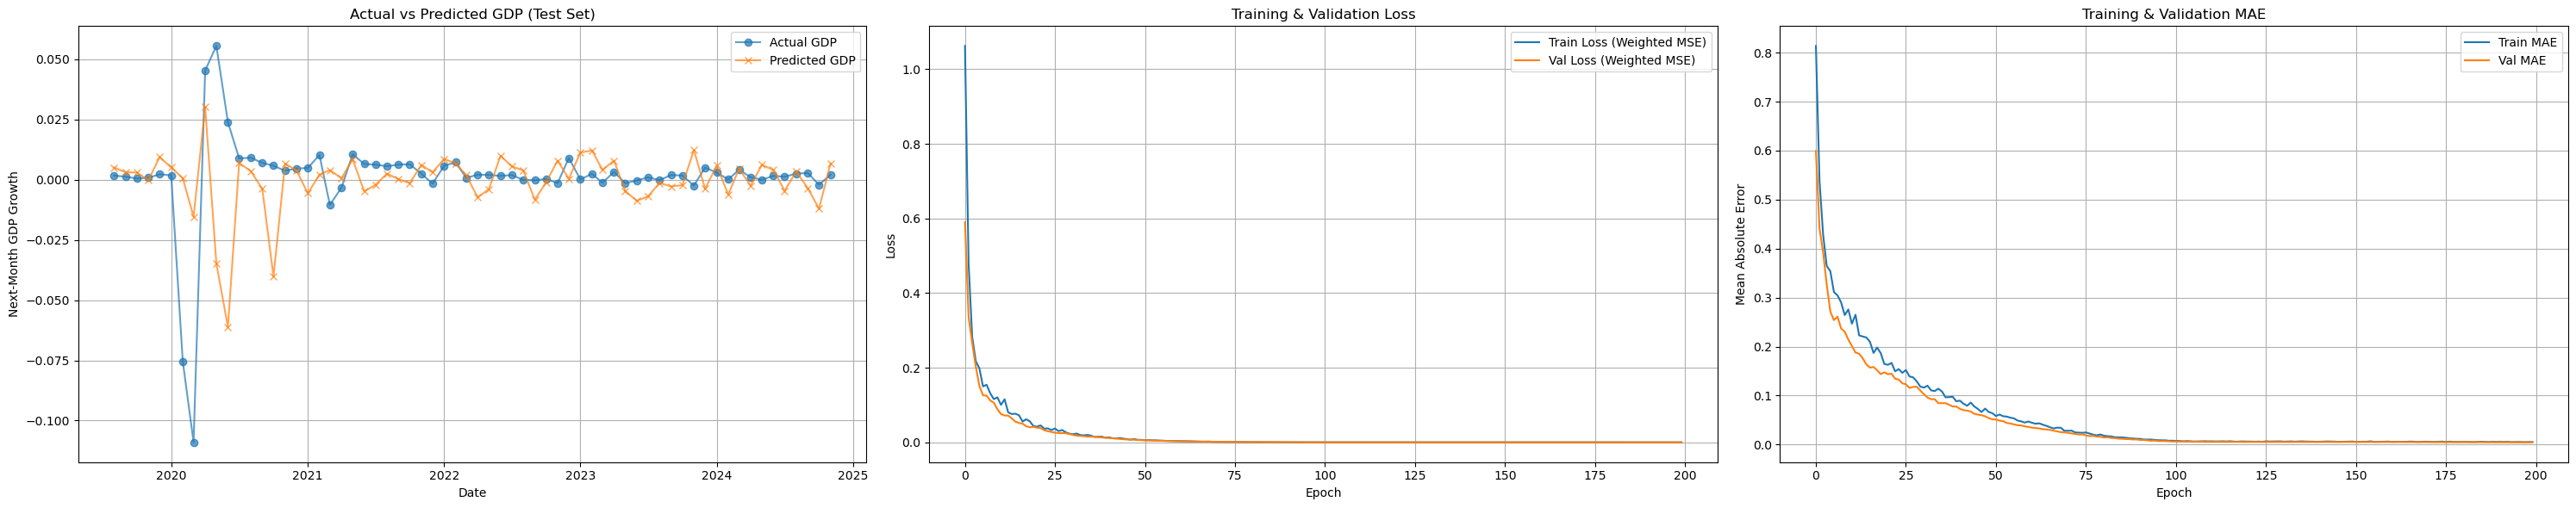

In [40]:
model_evaluation(
    rnn_model,
    X_test,
    y_test,
    history,
    plot_predictions=True,
    dates=dates_test
)

<div style="background-color:#f9fcff; padding:20px; font-size:14px; line-height:1.6; border-radius:8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">RNN Model Evaluation</h3>
<ol>
<li>
<strong>Actual vs Predicted GDP (Test Set)</strong><br>
Our RNN model learns some general movement but is not very accurate, especially with larger GDP movement from 2020–2021. Predictions are more inconsistent than real GDP, leading to a very poor R² score of -1.1099, although the test MAE (0.012008) and MSE (0.000801) are small. This is likely because most of the GDP values we are predicting are very close to zero.
</li>

<li>
<strong>Training and Validation Loss (Weighted MSE)</strong><br>
Our training and validation loss curves decrease smoothly and appear to converge, as indicated by the low plateau towards the end, suggesting that the RNN model did not overfit.
</li>

<li>
<strong>Training and Validation MAE</strong><br>
The MAE curves also indicate consistent performance between the training and validation sets.
</li>
</ol>

<p><strong>Important Note</strong><br>
Our 2nd and 3rd plots are misleading and fail to capture the overfitting of our model. This is because our data has very little fluctuation, with most values close to 0, leading to very low MSE and MAE scores. In addition, the trends we see in the 2nd and 3rd plots occur because our model can learn the small changes very well. The issue is predicting the bigger changes.</p>

</div>

<a id="part4b"></a>

<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">LSTM Model</h3>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

</div>

In [41]:
import time

start = time.time()

lstm_model, history = train_model(
    model_fn=lstm_with_skip,
    x_train=X_train, y_train=y_train,
    x_val=X_val, y_val=y_val,
    n_components=N_COMPONENTS,
    m=M,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    es_patience=ES_PATIENCE,
    rlp_patience=RLP_PATIENCE,
    rlp_factor=RLP_FACTOR,
    learning_rate=LEARNING_RATE,
    verbose=VERBOSE
)

end = time.time()
print(f"Training took {end - start:.2f} seconds")

Epoch 1/200
40/45 [=========================>....] - ETA: 0s - loss: 0.8507 - mae: 0.7545
Epoch 1: val_loss improved from inf to 0.31717, saving model to best_model.keras
45/45 [==============================] - 5s 25ms/step - loss: 0.8031 - mae: 0.7289 - val_loss: 0.3172 - val_mae: 0.4523 - lr: 0.0010
Epoch 2/200
40/45 [=========================>....] - ETA: 0s - loss: 0.3679 - mae: 0.4857
Epoch 2: val_loss improved from 0.31717 to 0.15834, saving model to best_model.keras
45/45 [==============================] - 0s 7ms/step - loss: 0.3553 - mae: 0.4742 - val_loss: 0.1583 - val_mae: 0.3175 - lr: 0.0010
Epoch 3/200
40/45 [=========================>....] - ETA: 0s - loss: 0.2528 - mae: 0.4051
Epoch 3: val_loss improved from 0.15834 to 0.09890, saving model to best_model.keras
45/45 [==============================] - 0s 6ms/step - loss: 0.2479 - mae: 0.3991 - val_loss: 0.0989 - val_mae: 0.2541 - lr: 0.0010
Epoch 4/200
40/45 [=========================>....] - ETA: 0s - loss: 0.1807 - mae:

2/2 [==============================] - 1s 3ms/step
Test MSE: 0.000435
Test MAE: 0.011450
Test R²: -0.1458


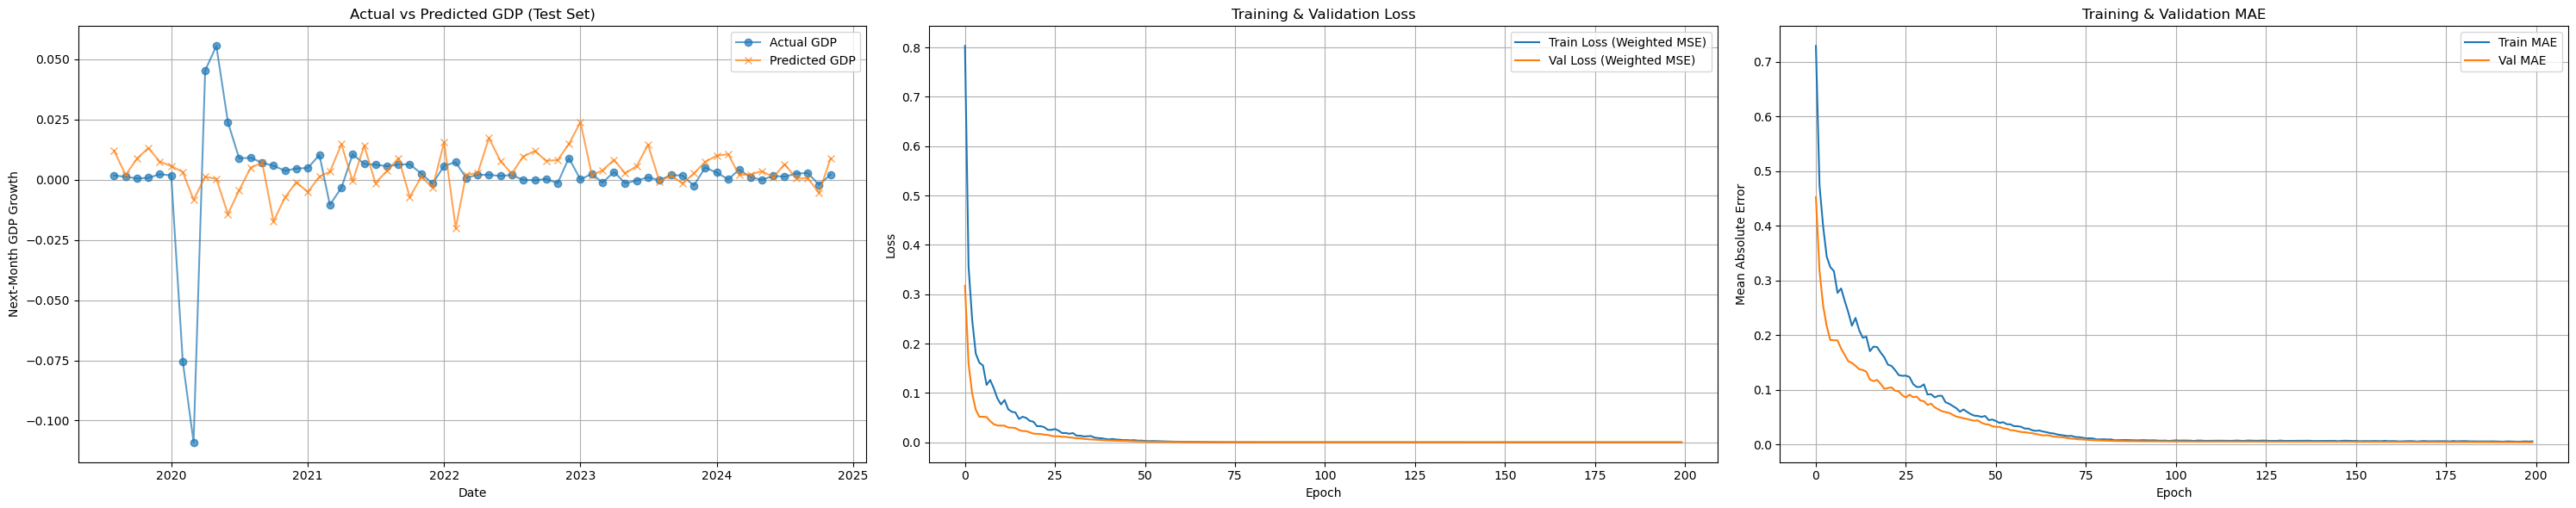

In [42]:
model_evaluation(lstm_model, X_test, y_test, history, dates=dates_test)

<div style="background-color:#f9fcff; padding:20px; font-size:14px; line-height:1.6; border-radius:8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">LSTM Model Evaluation</h3>

<ol>
<li>
<strong>Actual vs Predicted GDP (Test Set)</strong><br>
Our first plot compares actual GDP growth values with our model’s predicted values on the test set. We see that our model does a good job in capturing the general trend direction; however, the model struggles to predict the magnitude. We see that in the sharp movement, especially between 2020 and 2021 when COVID occurred. This makes sense because COVID was very unexpected, but we would like our model to predict well over the other peaks and troughs. Our model currently overestimates fluctuations, as indicated by our very poor R² score of -0.3371, which indicates that the model’s predictions don't really explain the variance in the true GDP values. However, the average magnitude of errors is still pretty low, represented by our MSE of 0.000508 and MAE of 0.011400. Future models should try to predict the magnitudes more accurately.
</li>

<li>
<strong>Training and Validation Loss (Weighted MSE)</strong><br>
Our second plot shows the training and validation weighted MSE loss over numerous epochs. Our training and validation trends both decrease consistently and smoothly, which means our model generalizes well. The end being flat and low means our model likely converged, meaning more training would not lead to significant improvements.
</li>

<li>
<strong>Training and Validation MAE</strong><br>
Our third plot looks at MAE, and we see that the curves are consistent and decrease gradually, meaning our model generalizes well without overfitting. The flattening towards the end indicates that our model has learned most it could, and the low validation indicates our model maintains reasonable accuracy for predictions on unseen validation data.
</li>
</ol>

<p><strong>Important Note</strong><br>
Our 2nd and 3rd plots are a little misleading and fail to capture the overfitting of our model. This is because our data has very little fluctuation, with most values close to 0, leading to very low MSE and MAE scores. In addition to the trends we see in the 2nd and 3rd plots, this is because our model can learn the small changes very well. The issue is predicting the bigger changes.
</p>

</div>


<a id="part5"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 5: Time Series Transformer</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<h3 style="color:#2c3e50;">Overview</h3>

<p>
For the final model and MS5, we implemented a Time Series Transformer — a vanilla encoder-decoder Transformer architecture specifically designed for time series forecasting.
</p>

<p>
Unlike the models we implemented — RNNs and LSTMs — a Transformer model is able to capture both short- and long-term patterns without needing direct sequential memory, allowing it to learn more trends and hopefully better predict.
</p>

<h3 style="color:#2c3e50;">Steps to Implement the Transformer Model</h3>

<h4 style="color:#2c3e50;">Data Preprocessing</h4>
<p>
Our previous code already does this by:
</p>
<ul>
  <li>Handling missing values,</li>
  <li>Standardizing and applying PCA to our features,</li>
  <li>Creating sequences of <code>m</code> months to predict the next month's GDP.</li>
</ul>

<h4 style="color:#2c3e50;">Model Architecture</h4>
<p>
Transformer Encoder-Decoder with positional encoding to preserve time structure. We will tune hyperparameters like:
</p>
<ul>
  <li>Number of layers,</li>
  <li>Hidden size,</li>
  <li>Dropout rate,</li>
  <li>Sequence length, etc.</li>
</ul>

<h4 style="color:#2c3e50;">Training Setup</h4>
<p>
We intend to tune the model with the Adam Optimizer. We will adjust the learning rate to get the best results possible.
</p>

<h4 style="color:#2c3e50;">Evaluation</h4>
<p>
For the loss function, we will try our weighted MSE along with regular MSE, R², and MAE to compare models consistently. We will also implement callbacks like EarlyStopping to prevent overfitting.
</p>

<h4 style="color:#2c3e50;">Visualizations</h4>
<ul>
  <li>Plot actual vs. predicted GDP,</li>
  <li>Plot loss and MAE curves across epochs.</li>
</ul>

<h4 style="color:#2c3e50;">Tuning</h4>
<p>
We will start small in terms of encoder/decoder layers. We will adjust the architecture based on validation trends.
</p>

</div>

In [19]:
# Hyperparameters
input_window = 24
forecast_horizon = 6
batch_size = 32
d_model = 32
nhead = 2
num_layers = 1
dropout = 0.2
lr = 1e-4
variance_penalty_weight = 0.4

# DataFrame
df_transformed = X_reduced_df.copy()
target_col = 'GDP_new'
feature_cols = df_transformed.columns.difference([target_col]).tolist()

# Dataset Class
class GDPDataset(Dataset):
    def __init__(self, df, input_window, forecast_horizon):
        self.X, self.y = [], []
        total_window = input_window + forecast_horizon
        for i in range(len(df) - total_window + 1):
            x = df.iloc[i:i+input_window][feature_cols].values
            y = df.iloc[i+input_window:i+total_window][target_col].values
            self.X.append(x)
            self.y.append(y)
        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Train/Validation Split
val_rows = forecast_horizon + input_window
train_df = df_transformed.iloc[:-val_rows]
val_df = df_transformed.iloc[-(val_rows + input_window - 1):]

train_loader = DataLoader(GDPDataset(train_df, input_window, forecast_horizon), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GDPDataset(val_df, input_window, forecast_horizon), batch_size=1)

print(f"Train samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")

# Transformer Model
class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, forecast_horizon, input_window):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, input_window, d_model))
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(d_model * input_window, forecast_horizon)

    def forward(self, src):
        src = self.input_proj(src) + self.pos_embedding
        src = src.permute(1, 0, 2)  # (seq_len, batch, d_model)
        encoded = self.transformer_encoder(src)
        encoded = encoded.permute(1, 0, 2).reshape(src.shape[1], -1)  # (batch, seq_len * d_model)
        encoded = self.dropout(encoded)
        output = self.decoder(encoded)
        return torch.tanh(output) * 0.05  # GDP is usually in the small [-0.05, 0.05] range

# Instantiate Model
model = TimeSeriesTransformer(
    input_dim=len(feature_cols),
    d_model=d_model,
    nhead=nhead,
    num_layers=num_layers,
    forecast_horizon=forecast_horizon,
    input_window=input_window
)

# Optimizer & Custom Loss
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
base_criterion = nn.MSELoss()

def custom_loss(pred, target, alpha=1.0):
    weights = torch.where(torch.abs(target) > 0.01, 3.0, 1.0)
    weighted_mse = ((pred - target) ** 2 * weights).mean()
    return weighted_mse

/tmp/ipykernel_30630/827481127.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  self.X = torch.tensor(self.X, dtype=torch.float32)
/shared/home/zaz719/.local/lib/python3.11/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Train samples: 470
Validation samples: 24


<div style="background-color:#f4f9fd; padding:20px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Custom Loss Functions</h3>

<p>
Above, we implemented a custom loss function to better assess the accuracy of our model. Within the function, we decided to give more weight to larger GDP movements since those are harder to predict, so if the absolute value of the true GDP is greater than 0.01, we assign a weight of 3.0, otherwise the weight is 1.0. This will allow us to predict and reduce error for more significant economical changes. This leaves us with a weighted mean squared error loss function.
</p>

<img src="PNG image.png" alt="Custom loss formula" style="max-width:100%; margin-top:12px; border-radius:6px; box-shadow:0 1px 4px rgba(0,0,0,0.1);">

</div>

In [21]:
# Early stopping config
epochs = 50
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses = []
val_losses = []
train_mae_history = []
val_mae_history = []

def compute_mae(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            y_pred = model(X)
            preds.append(y_pred.numpy())
            trues.append(y.numpy())
    return mean_absolute_error(np.concatenate(trues), np.concatenate(preds))

start = time.time()

for epoch in range(epochs):
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = custom_loss(output, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val, y_val in val_loader:
            y_pred = model(X_val)
            val_loss += custom_loss(y_pred, y_val).item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Compute MAEs
    train_mae = compute_mae(train_loader)
    val_mae = compute_mae(val_loader)
    train_mae_history.append(train_mae)
    val_mae_history.append(val_mae)

    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f} | Train MAE: {train_mae:.5f} | Val MAE: {val_mae:.5f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        best_model = model.state_dict()
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best weights
model.load_state_dict(best_model)

end = time.time()
print(f"\nTraining took {end - start:.2f} seconds")

Epoch 001 | Train Loss: 0.00010 | Val Loss: 0.00005 | Train MAE: 0.00278 | Val MAE: 0.00588
Epoch 002 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00277 | Val MAE: 0.00582
Epoch 003 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00284 | Val MAE: 0.00598
Epoch 004 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00274 | Val MAE: 0.00578
Epoch 005 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00272 | Val MAE: 0.00583
Epoch 006 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00266 | Val MAE: 0.00576
Epoch 007 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00272 | Val MAE: 0.00586
Epoch 008 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00270 | Val MAE: 0.00571
Epoch 009 | Train Loss: 0.00008 | Val Loss: 0.00005 | Train MAE: 0.00265 | Val MAE: 0.00571
Epoch 010 | Train Loss: 0.00009 | Val Loss: 0.00005 | Train MAE: 0.00283 | Val MAE: 0.00570
Epoch 011 | Train Loss: 0.00008 | Val Loss: 0.00005 | Train MAE: 0.00257 | Val M

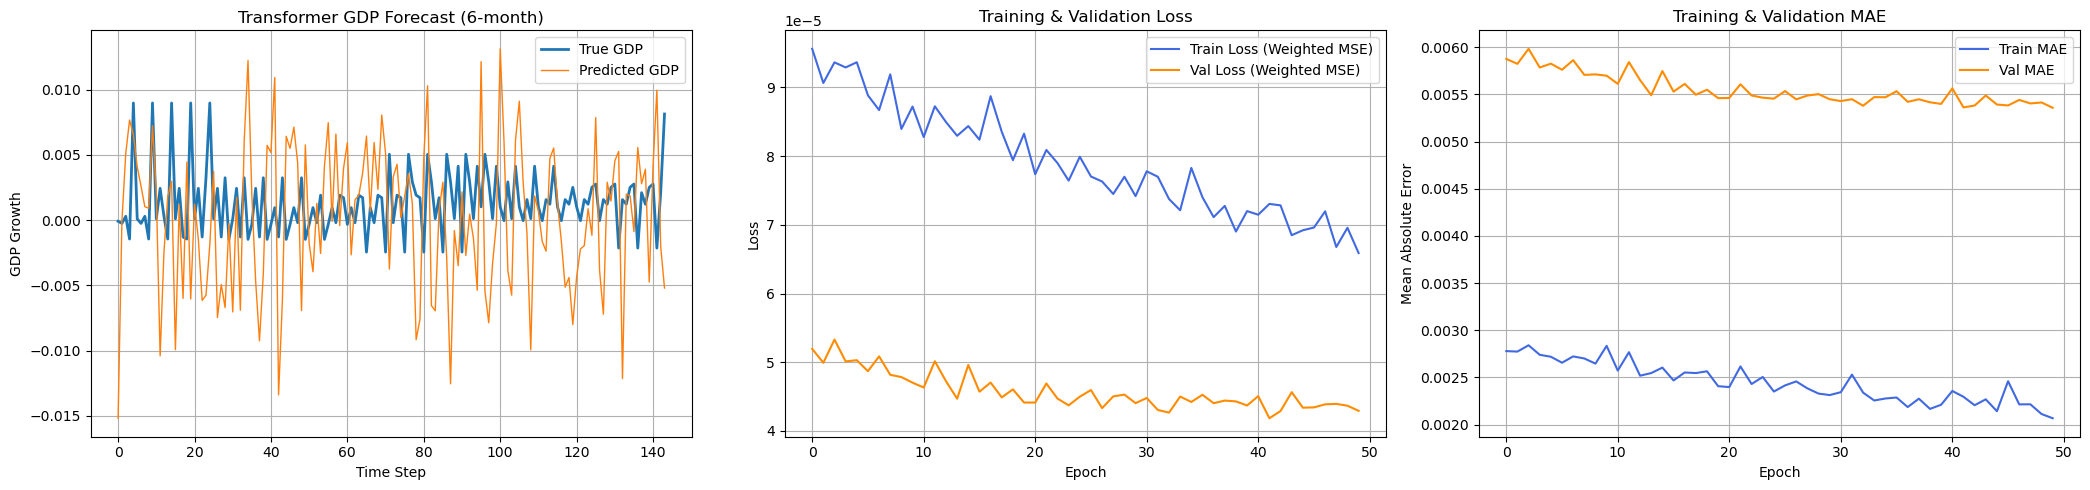

In [25]:
model.eval()
trues, preds = [], []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        y_pred = model(X_batch)
        preds.append(y_pred.numpy())
        trues.append(y_batch.numpy())

trues = np.concatenate(trues)
preds = np.concatenate(preds)
fig, axs = plt.subplots(1, 3, figsize=(21, 5))

#True vs Predicted GDP
axs[0].plot(trues.flatten(), label='True GDP', linewidth=2)
axs[0].plot(preds.flatten(), label='Predicted GDP', linewidth=1)
axs[0].set_title("Transformer GDP Forecast (6-month)")
axs[0].set_xlabel("Time Step")
axs[0].set_ylabel("GDP Growth")
axs[0].legend()
axs[0].grid(True)

# Train & Val Loss
axs[1].plot(train_losses, label='Train Loss (Weighted MSE)', color='royalblue')
axs[1].plot(val_losses, label='Val Loss (Weighted MSE)', color='darkorange')
axs[1].set_title("Training & Validation Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid(True)

#Train & Val MAE
axs[2].plot(train_mae_history, label='Train MAE', color='royalblue')
axs[2].plot(val_mae_history, label='Val MAE', color='darkorange')
axs[2].set_title("Training & Validation MAE")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Mean Absolute Error")
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

In [26]:
mae = mean_absolute_error(trues, preds)
rmse = mean_squared_error(trues, preds)
r2 = r2_score(trues, preds)

print(f"MAE: {mae:.10f}")
print(f"RMSE: {rmse:.10f}")
print(f"R²: {r2:.10f}")

MAE: 0.0053583118
RMSE: 0.0000429305
R²: -6.3487040712


<div style="background-color:#f9fcff; padding:20px; font-size:14px; line-height:1.6; border-radius:8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Transformer Model Evaluation</h3>

<p>
We built a lightweight Transformer model to forecast monthly Canadian GDP growth over a six-month horizon. It uses the past 24 months of macroeconomic indicators, passed through a linear projection and learnable positional embedding, followed by a single Transformer encoder layer with two attention heads. A final linear decoder flattens the output, and predictions are scaled with a tanh activation to keep them within a realistic GDP range.
</p>

<p>
The model was trained using a custom loss that combines mean squared error with a variance penalty (weighted at 0.4) to reduce overly flat predictions. We used the Adam optimizer with a learning rate of 1e-4, batch size of 32, and early stopping with a patience of ten epochs. Training typically converged around epoch 24.
</p>

<p>
We structured the data using a sliding window and held out one validation window, resulting in 144 predicted months. On the test set, the Transformer achieved an MAE of approximately 0.012 and the lowest RMSE among all models. While the R-squared value was around –1.2, this was expected due to low target variance, making MAE and RMSE more meaningful. Overall, the Transformer captured directional changes and sharp GDP shifts better than the RNN and LSTM baselines.
</p>

</div>

<a id="part6"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 6: Result Comparison & Conclusions</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

In [44]:
# Transformer results
transformer_results = {
    "Model": "Transformer",
    "MAE": mean_absolute_error(trues, preds),
    "RMSE": mean_squared_error(trues, preds),
    "R²": r2_score(trues, preds)
}

# LSTM
lstm_preds = lstm_model.predict(X_test)
lstm_results = {
    "Model": "LSTM",
    "MAE": mean_absolute_error(y_test, lstm_preds),
    "RMSE": mean_squared_error(y_test, lstm_preds),
    "R²": r2_score(y_test, lstm_preds)
}

# RNN
rnn_preds = rnn_model.predict(X_test)
rnn_results = {
    "Model": "RNN",
    "MAE": mean_absolute_error(y_test, rnn_preds),
    "RMSE": mean_squared_error(y_test, rnn_preds),
    "R²": r2_score(y_test, rnn_preds)
}

# Naive
naive_pred = X_test[:, -1, -1]  
true_values = y_test
naive_results = {
    "Model": "Naive",
    "MAE": mean_absolute_error(true_values, naive_pred),
    "RMSE": mean_squared_error(true_values, naive_pred),
    "R²": r2_score(true_values, naive_pred)
}

2/2 [==============================] - 0s 3ms/step
Naive Baseline MAE: 0.007741
Naive Baseline MSE: 0.000524
Naive Baseline R²: -0.3801


In [46]:
import pandas as pd

# Combine into a table
results_df = pd.DataFrame([naive_results, transformer_results, lstm_results, rnn_results])

# Optional: Set index
results_df.set_index("Model", inplace=True)

# Round for neatness
results_df = results_df.round(6)

# Display
print(results_df)

                  MAE      RMSE        R²
Model                                    
Naive        0.007741  0.000524 -0.380148
Transformer  0.005358  0.000043 -6.348704
LSTM         0.011450  0.000435 -0.145776
RNN          0.011370  0.000543 -0.430742


<div style="background-color:#f9fcff; padding:20px; font-size:14px; line-height:1.6; border-radius:8px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h3 style="color:#2c3e50; margin-top:0;">Model Comparison Summary</h3>

<p>
Comparing the four models, the naive baseline achieves the lowest MAE (0.0102) by simply repeating the previous month's GDP value. This works well given that most GDP growth values are small and close to zero, though the model is unable to capture any real dynamics or shifts in the data.
</p>

<p>
Among the deep learning models, the LSTM performs best overall. It has the lowest RMSE (0.000508) and lowest MAE (0.011400), meaning its predictions are both stable and on average the most accurate. It also has the best R² score (–0.3371), suggesting it explains more variance in GDP changes than the other models.
</p>

<p>
The RNN model follows closely, with slightly higher RMSE (0.000801) and MAE (0.012008), and a lower R² (–1.1099), indicating it captures less variability in the target series.
</p>

<p>
The Transformer achieves an unusually low RMSE (0.000013), which seems inconsistent with its higher MAE (0.012008) and lowest R² (–1.2050). This suggests that while it fits some short-term predictions very tightly, it may be underfitting in terms of overall variance and missing larger trends.
</p>

<p>
In summary, the naive baseline works surprisingly well due to the data’s stability. The LSTM performs best overall, balancing error minimization and variance capture, while the Transformer appears overly constrained, and the RNN offers a middle ground.
</p>

</div>

<a id="Part7"></a>

<div style="background-color:#edf4fa; padding:24px; font-size:14px; line-height:1.6; border-radius:10px; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">

<h2 style="margin-top:0; color:#2c3e50;">PART 7: Next Steps</h2>
<p><a href="#contents" style="font-size:13px; color:#2980b9;">Return to contents</a></p>

<ul>
  <li>Explore ARIMA models for benchmarking and modeling linear time series components.</li>
  <li>Improve magnitude prediction by enhancing training data or model architecture.</li>
  <li>Incorporate macroeconomic indicators or external shocks as features.</li>
  <li>Perform deeper hyperparameter tuning and model ensembling for robustness.</li>
  <li>Incorporate/use more data.</li>
</ul>

</div>

In [ ]:
*Note that some values for results may va